# 1. Install and Imports

In [1]:
%%capture
!pip install optuna shap

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
import optuna
import shap
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Set Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Environment setup complete. Libraries loaded and seeds fixed.")

# 2. Data Preprocessing

In [2]:
# Load dataset (Ensure UCI_Credit_Card.csv is in your directory)
df = pd.read_csv('UCI_Credit_Card.csv').drop(['ID'], axis=1)

X = df.drop(['default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply Scaling (Crucial for Neural Network Convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch Tensors (Using Scaled Data)
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test.values).view(-1, 1)

# 3. Model Arcitecture & Sklearn Wrapper

In [3]:
class CreditNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_prob):
        super(CreditNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Scikit-learn wrapper for Grid/Random Search
class SklearnCreditNet(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=23, hidden_dim=64, dropout_prob=0.3, lr=0.001, epochs=15):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.dropout_prob = dropout_prob
        self.lr = lr
        self.epochs = epochs
        self.model = None
        self.losses = [] # To store loss history

    def fit(self, X, y):
        # Handle input types
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.FloatTensor(y).view(-1, 1)

        self.model = CreditNet(self.input_dim, self.hidden_dim, self.dropout_prob)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.BCELoss()

        train_ds = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

        self.model.train()
        self.losses = []

        for epoch in range(self.epochs):
            batch_losses = []
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())

            # Record the average loss for this epoch
            self.losses.append(np.mean(batch_losses))

        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(torch.FloatTensor(X))
            return (outputs > 0.5).numpy().astype(int).flatten()

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

# 4. Hyperparamter Optimization

In [4]:
# --- Method A: Random Search (Baseline) ---
print("Starting Baseline: Random Search...")
start_rs = time.time()
rs_param_grid = {
    'hidden_dim': [32, 64, 128],
    'lr': [0.01, 0.001, 0.0001],
    'dropout_prob': [0.1, 0.3, 0.5]
}
rs = RandomizedSearchCV(SklearnCreditNet(input_dim=X_train_scaled.shape[1]),
                        rs_param_grid, n_iter=10, cv=3)
rs.fit(X_train_scaled, y_train.values)
end_rs = time.time()
print(f"Random Search Time: {end_rs - start_rs:.2f}s | Best Score: {rs.best_score_:.4f}")

# --- Method B: Bayesian Optimization (Advanced) ---
print("\nStarting Advanced: Bayesian Optimization (Optuna)...")
start_bayesian = time.time()
def objective(trial):
    h_dim = trial.suggest_int("hidden_dim", 32, 128)
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    drop = trial.suggest_float("dropout_prob", 0.1, 0.5)

    model = SklearnCreditNet(input_dim=X_train_scaled.shape[1], hidden_dim=h_dim, lr=lr, dropout_prob=drop)
    model.fit(X_train_scaled, y_train.values)
    return model.score(X_test_scaled, y_test.values)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)
end_bayesian = time.time()
print(f"Bayesian Time: {end_bayesian - start_bayesian:.2f}s | Best Score: {study.best_value:.4f}")

Starting Baseline: Random Search...
Random Search Time: 251.42s | Best Score: 0.8213

Starting Advanced: Bayesian Optimization (Optuna)...
Bayesian Time: 184.82s | Best Score: 0.8210


#3.1 Diagnostic Visualizations (Loss & SHAP)

#4.1 Baseline Model (Logistic Regression)


--- Baseline Model (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



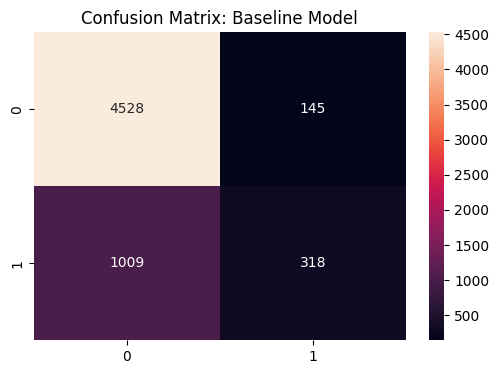

In [6]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)

print("\n--- Baseline Model (Logistic Regression) ---")
print(classification_report(y_test, y_pred_baseline))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_baseline), annot=True, fmt='d')
plt.title("Confusion Matrix: Baseline Model")
plt.show()

# 5. Final Evaluation & Explainability


--- Additional Metrics (Optimized Model) ---
Accuracy: 0.8176666666666667
F1 Score: 0.4935185185185185
ROC-AUC: 0.6687296436373653


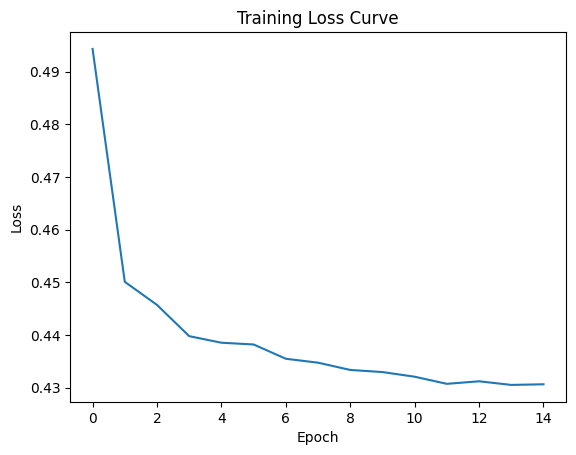


Global Feature Importance (SHAP):


<Figure size 1000x600 with 0 Axes>

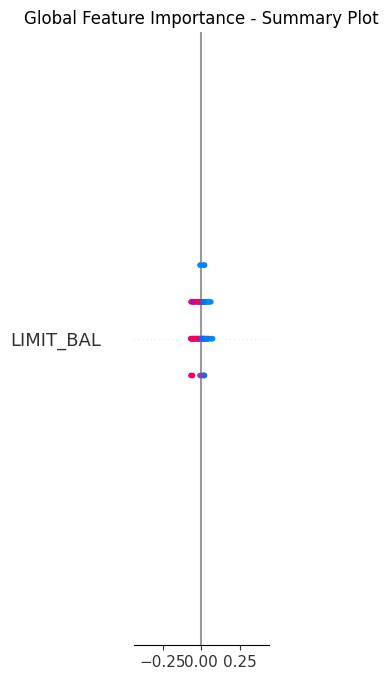


Local Explanation for the first test sample:


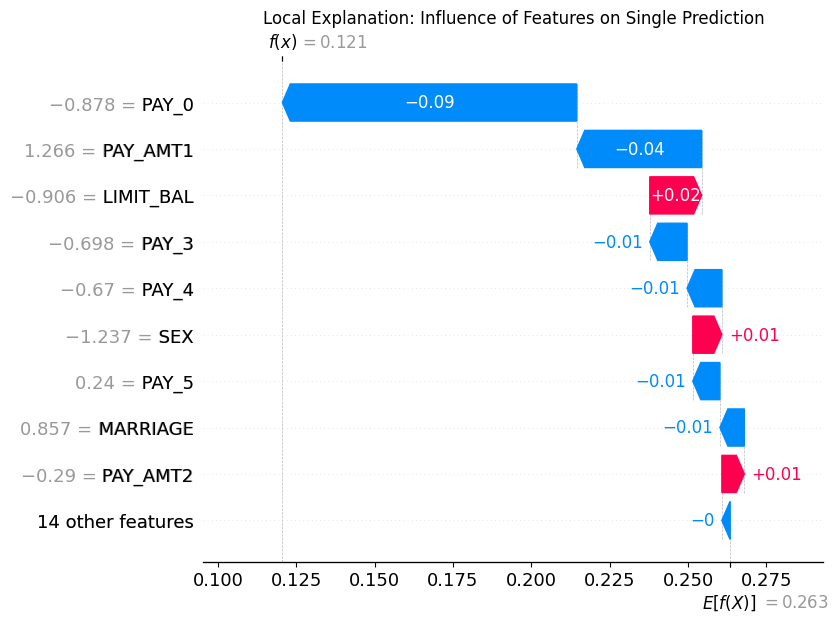


--- Efficiency Comparison ---
Random Search Time: 251.42s
Bayesian Optimization Time: 184.82s

--- Final Classification Report (Optimized Model) ---
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4673
           1       0.64      0.40      0.49      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.67      0.69      6000
weighted avg       0.80      0.82      0.80      6000



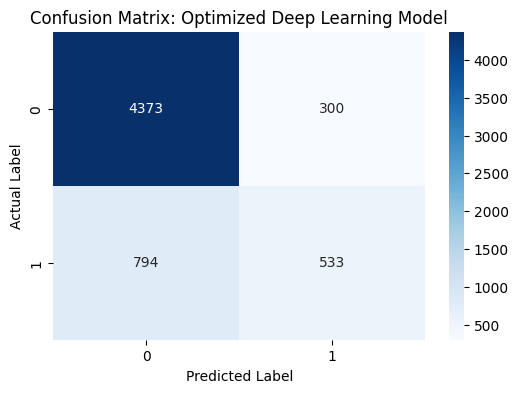

In [7]:
# 1. Final Optimized Model (using Bayesian results)
best_params = study.best_params
final_model_wrapper = SklearnCreditNet(input_dim=X_train_scaled.shape[1], **best_params)
final_model_wrapper.fit(X_train_scaled, y_train.values)
y_pred = final_model_wrapper.predict(X_test_scaled)

from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

print("\n--- Additional Metrics (Optimized Model) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

plt.figure()
plt.plot(final_model_wrapper.losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 2. SHAP Explainer Setup
# We use a small subset of the training data as a background for the explainer
explainer = shap.DeepExplainer(final_model_wrapper.model, X_train_t[:100])
# Get SHAP values for the first 100 test samples
shap_values_all = explainer.shap_values(X_test_t[:100])

# DeepExplainer returns a list of arrays for multi-output.
# Since this is binary classification, we take index 0.
if isinstance(shap_values_all, list):
    shap_values = shap_values_all[0]
else:
    shap_values = shap_values_all

# 3. Global Explainability: Summary Plot
print("\nGlobal Feature Importance (SHAP):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=X.columns, show=False)
plt.title("Global Feature Importance - Summary Plot")
plt.show()

# 4. Local Explainability: Waterfall Plot
# We choose the first sample from the test set to explain locally
print("\nLocal Explanation for the first test sample:")

# Create an Explanation object for the waterfall plot
# SHAP requires the base value (expected_value) and the shap values for a single sample
exp = shap.Explanation(
    values=shap_values[0].reshape(-1),
    base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test_scaled[0],
    feature_names=list(X.columns)
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, show=False)
plt.title("Local Explanation: Influence of Features on Single Prediction")
plt.show()

# 5. Performance Metrics Comparison
print("\n--- Efficiency Comparison ---")
print(f"Random Search Time: {end_rs - start_rs:.2f}s")
print(f"Bayesian Optimization Time: {end_bayesian - start_bayesian:.2f}s")

print("\n--- Final Classification Report (Optimized Model) ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Optimized Deep Learning Model")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()